# 岡山市中心部の滞在人口比較

In [36]:
import pandas as pd
import seaborn as sns

In [37]:

w_df = pd.read_csv('area1_month_weekdays.csv', encoding="cp932")
w_df.head()

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上
0,2018-1,平日,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8
1,2018-2,平日,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6
2,2018-3,平日,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9
3,2018-4,平日,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1
4,2018-5,平日,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6


In [38]:
w_df = w_df.drop(["Unnamed: 1"], axis=1)

w_df = w_df.rename(columns={"Unnamed: 0": "ds"})
w_df['ds'] = pd.to_datetime(w_df['ds'])
w_df

,ds,男性,女性,20代,30代,40代,50代,60代,70歳以上
0,2018-01-01,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8
1,2018-02-01,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6
2,2018-03-01,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9
3,2018-04-01,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1
4,2018-05-01,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6
...,...,...,...,...,...,...,...,...,...
83,2024-12-01,1505.8,1498.6,615.3,477.5,586.1,482.9,384.5,458.1
84,2025-01-01,1379.4,1384.6,584.5,451.9,522.8,450.5,350.5,403.8
85,2025-02-01,1207.9,1203.9,486.1,387.6,468.4,400.1,308.0,361.6
86,2025-03-01,1385.3,1423.0,573.1,431.2,538.7,461.0,366.6,437.7


In [39]:
pip install japanize-matplotlib

In [40]:
#折れ線グラフを作成
import matplotlib.pyplot as plt

In [41]:
#横持ちのデータを縦持ちに変換
df_melted = w_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
df_melted['ds'] = pd.to_datetime(df_melted['ds'])

df_melted

,ds,Category,Value
0,2018-01-01,男性,1791.2
1,2018-02-01,男性,1626.6
2,2018-03-01,男性,1903.0
3,2018-04-01,男性,1764.6
4,2018-05-01,男性,1835.4
...,...,...,...
699,2024-12-01,70歳以上,458.1
700,2025-01-01,70歳以上,403.8
701,2025-02-01,70歳以上,361.6
702,2025-03-01,70歳以上,437.7


In [42]:
import japanize_matplotlib

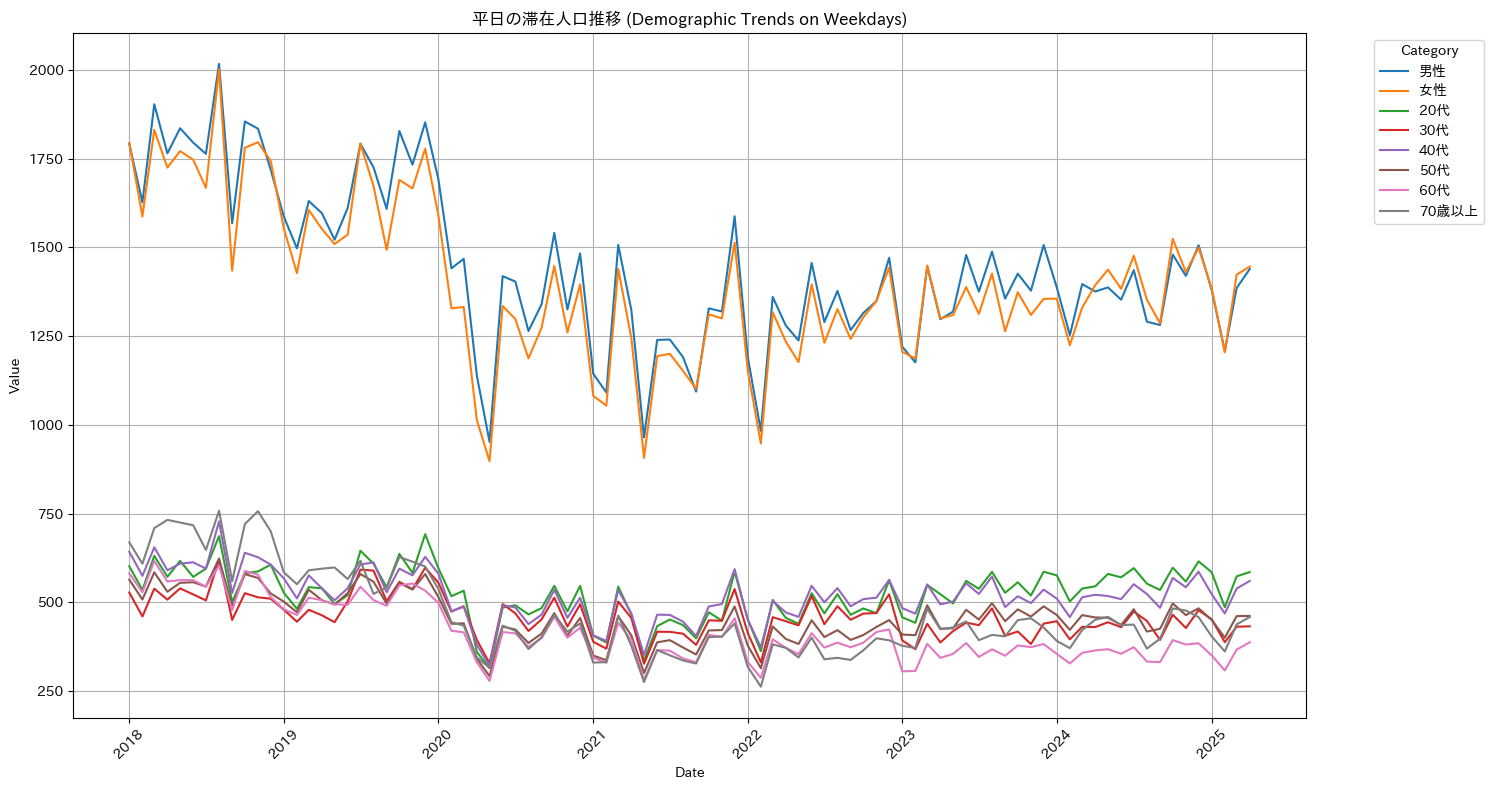

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

df_melted_numeric = df_melted[df_melted['Category'] != 'Unnamed: 1'].copy()
df_melted_numeric['Value'] = pd.to_numeric(df_melted_numeric['Value'])

plt.figure(figsize=(15, 8))
sns.lineplot(data=df_melted_numeric, x='ds', y='Value', hue='Category')
plt.title('平日の滞在人口推移 (Demographic Trends on Weekdays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [44]:

holiday_df = pd.read_csv("area1_month_holidays.csv", encoding="cp932")
h_df = holiday_df
h_df

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上
0,2018-1,祝休日,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018-2,祝休日,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018-3,祝休日,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018-4,祝休日,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018-5,祝休日,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2
...,...,...,...,...,...,...,...,...,...,...
83,2024-12,祝休日,616.8,642.5,284.1,222.8,255.2,189.8,139.5,167.9
84,2025-1,祝休日,597.5,639.8,277.9,213.3,245.2,190.0,141.3,169.5
85,2025-2,祝休日,605.5,663.6,283.3,218.5,251.3,193.8,143.4,178.8
86,2025-3,祝休日,701.3,782.5,327.2,245.9,293.5,236.3,172.8,208.0


In [45]:
h_df = h_df.drop(["Unnamed: 1"], axis=1)

h_df = h_df.rename(columns={"Unnamed: 0": "ds"})
h_df['ds'] = pd.to_datetime(w_df['ds'])

#横持ちのデータを縦持ちに変換
h_df_melted = h_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
h_df_melted['ds'] = pd.to_datetime(h_df_melted['ds'])

h_df_melted

,ds,Category,Value
0,2018-01-01,男性,741.6
1,2018-02-01,男性,705.0
2,2018-03-01,男性,832.1
3,2018-04-01,男性,834.9
4,2018-05-01,男性,846.1
...,...,...,...
699,2024-12-01,70歳以上,167.9
700,2025-01-01,70歳以上,169.5
701,2025-02-01,70歳以上,178.8
702,2025-03-01,70歳以上,208.0


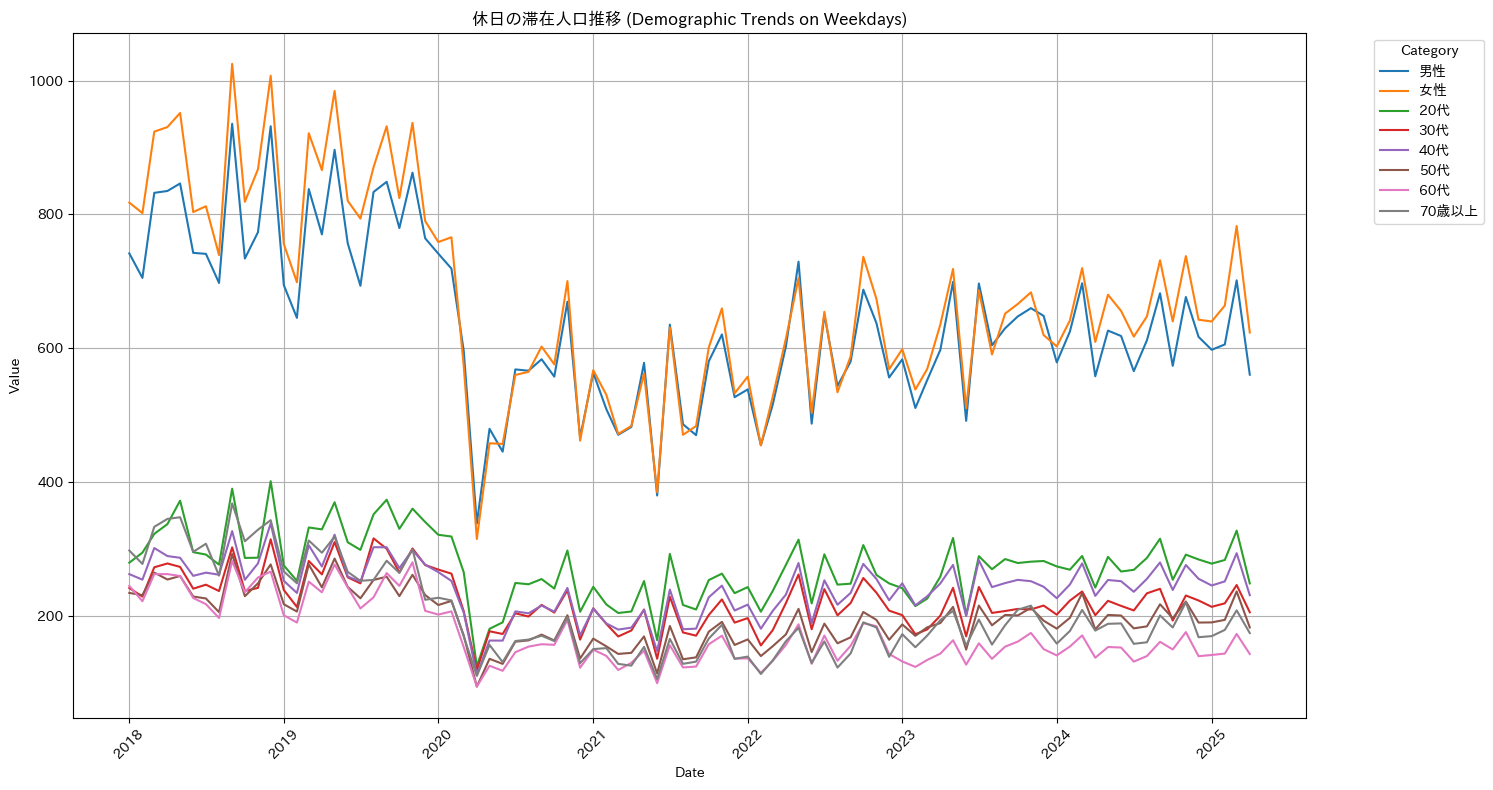

In [46]:
h_df_melted_numeric = h_df_melted[h_df_melted['Category'] != 'Unnamed: 1'].copy()
h_df_melted_numeric['Value'] = pd.to_numeric(h_df_melted_numeric['Value'])

plt.figure(figsize=(15, 8))
sns.lineplot(data=h_df_melted_numeric, x='ds', y='Value', hue='Category')
plt.title('休日の滞在人口推移 (Demographic Trends on Weekdays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 岡南地域の平日と休日の滞在人口比較

In [47]:
kounan_df = pd.read_csv('kounan_month.csv', encoding="cp932", header=1)
kounan_df.head()

,岡南,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,468.1,481.3,126.2,132.7,185.2,151.4,199.8,154.2,...,NaN,祝休日,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4
1,2018年2月,期間全体,430.7,444.4,116.8,120.7,161.2,142.9,188.2,145.3,...,NaN,祝休日,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5
2,2018年3月,期間全体,477.4,516.8,129.5,148.0,197.3,162.9,202.7,153.7,...,NaN,祝休日,162.8,176.7,43.0,55.8,67.8,56.1,69.1,47.6
3,2018年4月,期間全体,475.7,583.3,142.8,148.2,176.1,160.6,196.5,234.6,...,NaN,祝休日,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7
4,2018年5月,期間全体,484.0,553.0,134.3,146.0,174.8,164.1,209.8,208.1,...,NaN,祝休日,164.8,190.7,49.3,50.9,61.8,56.0,66.8,70.7


In [48]:
#日付列の作成
kounan_df = kounan_df.rename(columns={'岡南': 'ds'})
kounan_df['ds'] = kounan_df['ds'].str.replace('年', '-').str.replace('月', '-01')
#文字列 → pandas の datetime 型 に変換
kounan_df['ds'] = pd.to_datetime(kounan_df['ds'])

#平日・休日共通の人口属性列を設定
demographic_columns = ['男性', '女性', '20代', '30代', '40代', '50代', '60代', '70歳以上']

#元データを残しつつ、平日の人口列を抜き出して新しいDataFrame
kounan_weekday_df = kounan_df[['ds'] + demographic_columns].copy()

#
holiday_cols_mapping = {col_with_suffix: col for col_with_suffix, col in zip([f'{col}.2' for col in demographic_columns], demographic_columns)}
#休日列だけを抽出
kounan_holiday_df = kounan_df[['ds'] + list(holiday_cols_mapping.keys())].copy()
kounan_holiday_df = kounan_holiday_df.rename(columns=holiday_cols_mapping)

#確認用
print("Kounan Weekday DataFrame Head:")
print(kounan_weekday_df.head())
print("\nKounan Holiday DataFrame Head:")
print(kounan_holiday_df.head())

Kounan Weekday DataFrame Head:
          ds     男性     女性    20代    30代    40代    50代    60代  70歳以上
0 2018-01-01  468.1  481.3  126.2  132.7  185.2  151.4  199.8  154.2
1 2018-02-01  430.7  444.4  116.8  120.7  161.2  142.9  188.2  145.3
2 2018-03-01  477.4  516.8  129.5  148.0  197.3  162.9  202.7  153.7
3 2018-04-01  475.7  583.3  142.8  148.2  176.1  160.6  196.5  234.6
4 2018-05-01  484.0  553.0  134.3  146.0  174.8  164.1  209.8  208.1

Kounan Holiday DataFrame Head:
          ds     男性     女性   20代   30代   40代   50代   60代  70歳以上
0 2018-01-01  149.9  160.3  40.9  46.3  62.2  51.9  65.5   43.4
1 2018-02-01  140.8  140.9  36.1  44.2  54.3  47.3  61.4   38.5
2 2018-03-01  162.8  176.7  43.0  55.8  67.8  56.1  69.1   47.6
3 2018-04-01  169.6  216.2  51.9  59.5  65.4  57.6  66.8   84.7
4 2018-05-01  164.8  190.7  49.3  50.9  61.8  56.0  66.8   70.7


In [49]:
kounan_weekday_melted = kounan_weekday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
kounan_weekday_melted['DayType'] = 'Weekday'

kounan_holiday_melted = kounan_holiday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
kounan_holiday_melted['DayType'] = 'Holiday'

kounan_weekday_melted['Value'] = pd.to_numeric(kounan_weekday_melted['Value'])
kounan_holiday_melted['Value'] = pd.to_numeric(kounan_holiday_melted['Value'])

kounan_combined_df = pd.concat([kounan_weekday_melted, kounan_holiday_melted], ignore_index=True)

print("Kounan Combined DataFrame Head:")
print(kounan_combined_df.head())
print("\nKounan Combined DataFrame Tail:")
print(kounan_combined_df.tail())

Kounan Combined DataFrame Head:
          ds Category  Value  DayType
0 2018-01-01       男性  468.1  Weekday
1 2018-02-01       男性  430.7  Weekday
2 2018-03-01       男性  477.4  Weekday
3 2018-04-01       男性  475.7  Weekday
4 2018-05-01       男性  484.0  Weekday

Kounan Combined DataFrame Tail:
             ds Category  Value  DayType
1403 2024-12-01    70歳以上   64.3  Holiday
1404 2025-01-01    70歳以上   67.1  Holiday
1405 2025-02-01    70歳以上   65.2  Holiday
1406 2025-03-01    70歳以上   73.1  Holiday
1407 2025-04-01    70歳以上   58.5  Holiday


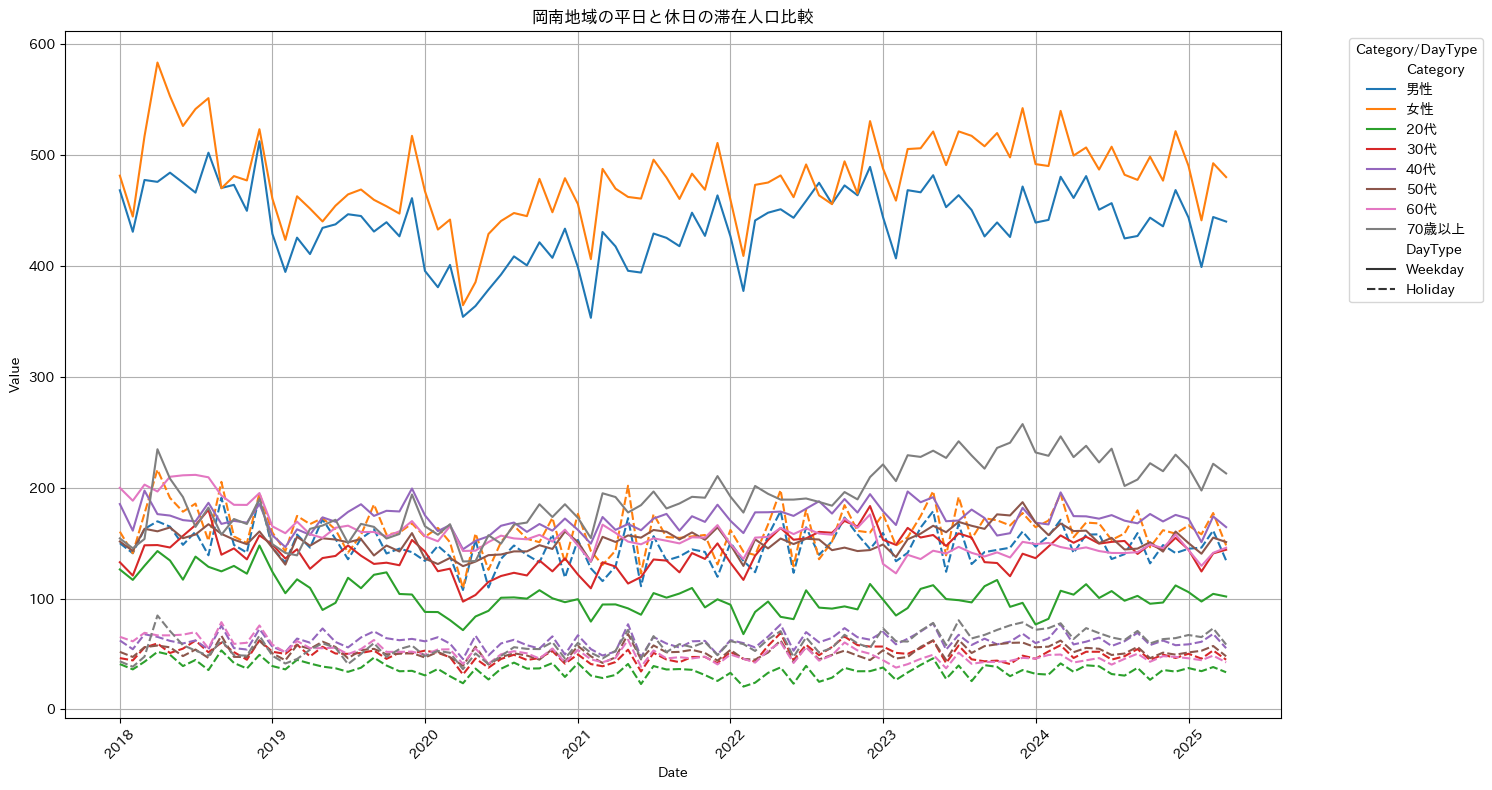

In [50]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=kounan_combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('岡南地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 北長瀬地域の平日と休日の滞在人口比較

In [51]:
kitanagase_df = pd.read_csv('kitanagase_month.csv', encoding="cp932", header=1)
kitanagase_df.head()

,北長瀬,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,470.3,495.7,166.1,176.1,186.7,142.1,133.8,161.2,...,NaN,祝休日,154.2,169.0,54.6,61.5,67.1,47.9,41.5,50.6
1,2018年2月,期間全体,412.7,434.6,162.7,161.2,171.3,121.3,121.1,109.6,...,NaN,祝休日,136.0,150.4,51.7,57.6,59.5,43.6,37.1,36.9
2,2018年3月,期間全体,491.3,504.1,192.2,171.8,199.1,131.2,138.0,163.1,...,NaN,祝休日,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8
3,2018年4月,期間全体,464.1,453.7,158.8,167.4,178.4,135.5,137.9,139.7,...,NaN,祝休日,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46.0
4,2018年5月,期間全体,488.4,470.4,195.9,165.1,186.7,138.2,128.6,144.4,...,NaN,祝休日,170.5,164.6,68.2,63.5,67.0,49.0,38.2,49.4


In [52]:
kitanagase_df = kitanagase_df.rename(columns={'北長瀬': 'ds'})
kitanagase_df['ds'] = kitanagase_df['ds'].str.replace('年', '-').str.replace('月', '-01')
kitanagase_df['ds'] = pd.to_datetime(kitanagase_df['ds'])

# Define common demographic columns
demographic_columns = ['男性', '女性', '20代', '30代', '40代', '50代', '60代', '70歳以上']

# Create kitanagase_weekday_df
kounan_weekday_df = kitanagase_df[['ds'] + demographic_columns].copy()
kounan_weekday_df.rename(columns={'男性': '男性', '女性': '女性', '20代': '20代', '30代': '30代', '40代': '40代', '50代': '50代', '60代': '60代', '70歳以上': '70歳以上'}, inplace=True)


# Create kitanagase_holiday_df
holiday_cols_mapping = {f'{col}.2': col for col in demographic_columns}
kounan_holiday_df = kitanagase_df[['ds'] + list(holiday_cols_mapping.keys())].copy()
kounan_holiday_df = kounan_holiday_df.rename(columns=holiday_cols_mapping)

print("Kitanagase Weekday DataFrame Head:")
print(kounan_weekday_df.head())
print("\nKitanagase Holiday DataFrame Head:")
print(kounan_holiday_df.head())

Kitanagase Weekday DataFrame Head:
          ds     男性     女性    20代    30代    40代    50代    60代  70歳以上
0 2018-01-01  470.3  495.7  166.1  176.1  186.7  142.1  133.8  161.2
1 2018-02-01  412.7  434.6  162.7  161.2  171.3  121.3  121.1  109.6
2 2018-03-01  491.3  504.1  192.2  171.8  199.1  131.2  138.0  163.1
3 2018-04-01  464.1  453.7  158.8  167.4  178.4  135.5  137.9  139.7
4 2018-05-01  488.4  470.4  195.9  165.1  186.7  138.2  128.6  144.4

Kitanagase Holiday DataFrame Head:
          ds     男性     女性   20代   30代   40代   50代   60代  70歳以上
0 2018-01-01  154.2  169.0  54.6  61.5  67.1  47.9  41.5   50.6
1 2018-02-01  136.0  150.4  51.7  57.6  59.5  43.6  37.1   36.9
2 2018-03-01  169.1  182.2  68.6  64.9  72.8  45.8  39.5   59.8
3 2018-04-01  166.1  169.1  60.3  65.5  67.5  51.2  44.7   46.0
4 2018-05-01  170.5  164.6  68.2  63.5  67.0  49.0  38.2   49.4


In [53]:
kitanagase_weekday_df = kounan_weekday_df.copy()
kitanagase_holiday_df = kounan_holiday_df.copy()

kitanagase_weekday_melted = kitanagase_weekday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
kitanagase_weekday_melted['DayType'] = 'Weekday'

kitanagase_holiday_melted = kitanagase_holiday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
kitanagase_holiday_melted['DayType'] = 'Holiday'

kitanagase_weekday_melted['Value'] = pd.to_numeric(kitanagase_weekday_melted['Value'])
kitanagase_holiday_melted['Value'] = pd.to_numeric(kitanagase_holiday_melted['Value'])

kitanagase_combined_df = pd.concat([kitanagase_weekday_melted, kitanagase_holiday_melted], ignore_index=True)

print("Kitanagase Combined DataFrame Head:")
print(kitanagase_combined_df.head())
print("\nKitanagase Combined DataFrame Tail:")
print(kitanagase_combined_df.tail())

Kitanagase Combined DataFrame Head:
          ds Category  Value  DayType
0 2018-01-01       男性  470.3  Weekday
1 2018-02-01       男性  412.7  Weekday
2 2018-03-01       男性  491.3  Weekday
3 2018-04-01       男性  464.1  Weekday
4 2018-05-01       男性  488.4  Weekday

Kitanagase Combined DataFrame Tail:
             ds Category  Value  DayType
1403 2024-12-01    70歳以上   36.4  Holiday
1404 2025-01-01    70歳以上   36.2  Holiday
1405 2025-02-01    70歳以上   39.6  Holiday
1406 2025-03-01    70歳以上   41.5  Holiday
1407 2025-04-01    70歳以上   37.0  Holiday


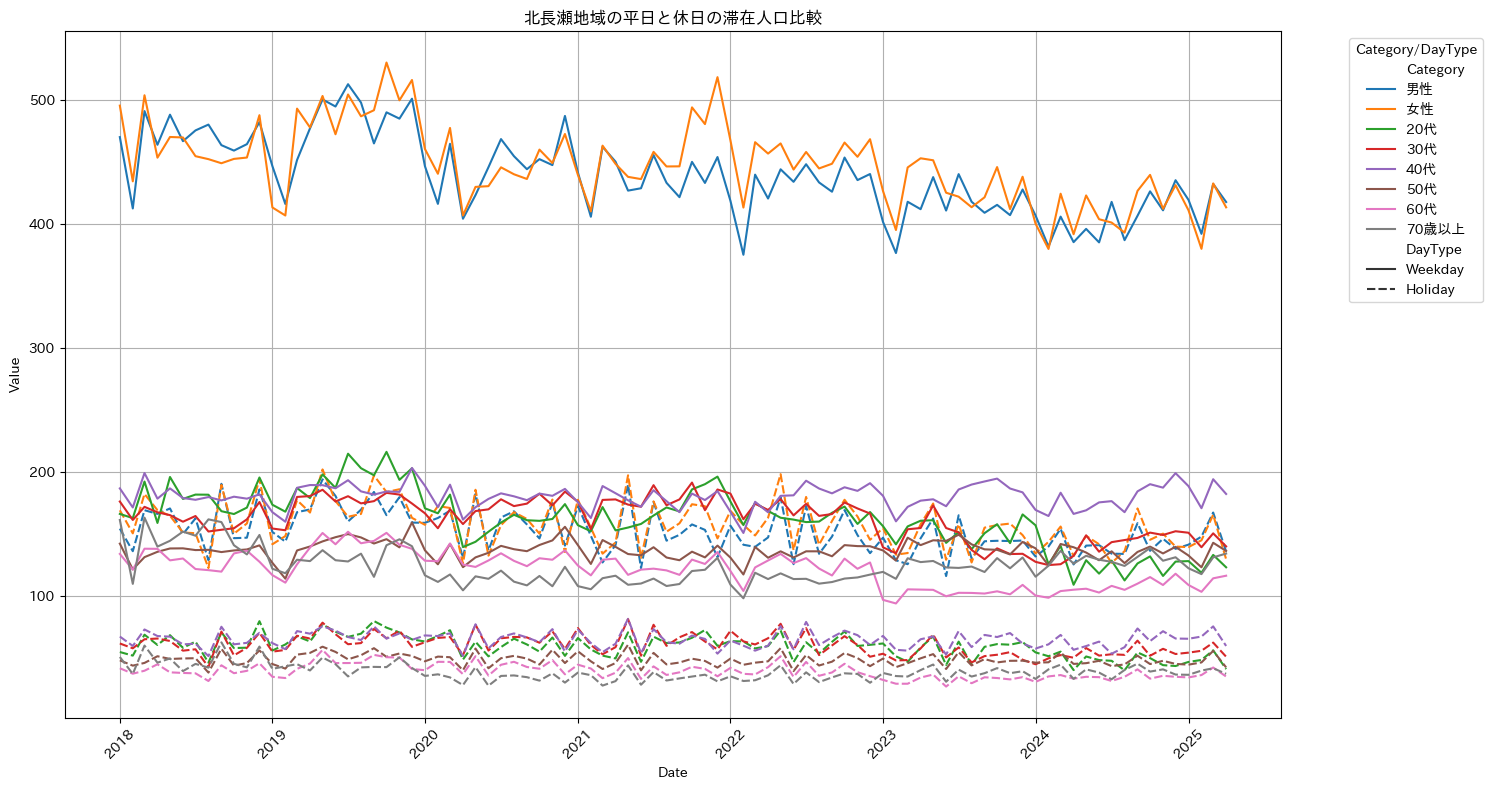

In [54]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=kitanagase_combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('北長瀬地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 浜・原尾島地域の平日と休日の滞在人口比較

In [55]:
hama_haraojima_df = pd.read_csv('hama_haraojima_month.csv', encoding="cp932", header=1)
hama_haraojima_df.head()

,浜・原尾島,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,434.1,552.3,129.9,144.5,175.0,151.8,202.1,183.1,...,NaN,祝休日,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6
1,2018年2月,期間全体,399.2,503.4,124.6,126.9,160.0,131.3,183.8,175.9,...,NaN,祝休日,131.2,174.8,42.0,43.4,52.4,44.3,56.6,67.3
2,2018年3月,期間全体,467.7,570.9,154.4,148.8,180.2,155.4,225.1,174.7,...,NaN,祝休日,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7
3,2018年4月,期間全体,469.7,566.4,143.9,161.6,174.6,147.4,203.2,205.4,...,NaN,祝休日,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68.0
4,2018年5月,期間全体,462.0,594.6,155.9,154.7,171.1,152.4,199.0,223.6,...,NaN,祝休日,159.4,199.3,55.9,54.9,57.5,50.0,61.5,78.8


In [56]:
hama_haraojima_df = hama_haraojima_df.rename(columns={'浜・原尾島': 'ds'})
hama_haraojima_df['ds'] = hama_haraojima_df['ds'].str.replace('年', '-').str.replace('月', '-01')
hama_haraojima_df['ds'] = pd.to_datetime(hama_haraojima_df['ds'])

# Define common demographic columns
demographic_columns = ['男性', '女性', '20代', '30代', '40代', '50代', '60代', '70歳以上']

# Create hama_haraojima_weekday_df
hama_haraojima_weekday_df = hama_haraojima_df[['ds'] + demographic_columns].copy()

# Create hama_haraojima_holiday_df
holiday_cols_mapping = {f'{col}.2': col for col in demographic_columns}
hama_haraojima_holiday_df = hama_haraojima_df[['ds'] + list(holiday_cols_mapping.keys())].copy()
hama_haraojima_holiday_df = hama_haraojima_holiday_df.rename(columns=holiday_cols_mapping)

print("Hama/Haraojima Weekday DataFrame Head:")
print(hama_haraojima_weekday_df.head())
print("\nHama/Haraojima Holiday DataFrame Head:")
print(hama_haraojima_holiday_df.head())

Hama/Haraojima Weekday DataFrame Head:
          ds     男性     女性    20代    30代    40代    50代    60代  70歳以上
0 2018-01-01  434.1  552.3  129.9  144.5  175.0  151.8  202.1  183.1
1 2018-02-01  399.2  503.4  124.6  126.9  160.0  131.3  183.8  175.9
2 2018-03-01  467.7  570.9  154.4  148.8  180.2  155.4  225.1  174.7
3 2018-04-01  469.7  566.4  143.9  161.6  174.6  147.4  203.2  205.4
4 2018-05-01  462.0  594.6  155.9  154.7  171.1  152.4  199.0  223.6

Hama/Haraojima Holiday DataFrame Head:
          ds     男性     女性   20代   30代   40代   50代   60代  70歳以上
0 2018-01-01  143.1  181.1  41.9  48.9  56.1  50.5  62.2   64.6
1 2018-02-01  131.2  174.8  42.0  43.4  52.4  44.3  56.6   67.3
2 2018-03-01  164.2  194.8  57.7  52.2  57.8  54.2  74.3   62.7
3 2018-04-01  168.9  195.8  54.3  59.7  60.7  53.6  68.5   68.0
4 2018-05-01  159.4  199.3  55.9  54.9  57.5  50.0  61.5   78.8


In [57]:
hama_haraojima_weekday_melted = hama_haraojima_weekday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
hama_haraojima_weekday_melted['DayType'] = 'Weekday'

hama_haraojima_holiday_melted = hama_haraojima_holiday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
hama_haraojima_holiday_melted['DayType'] = 'Holiday'

hama_haraojima_weekday_melted['Value'] = pd.to_numeric(hama_haraojima_weekday_melted['Value'])
hama_haraojima_holiday_melted['Value'] = pd.to_numeric(hama_haraojima_holiday_melted['Value'])

hama_haraojima_combined_df = pd.concat([hama_haraojima_weekday_melted, hama_haraojima_holiday_melted], ignore_index=True)

print("Hama/Haraojima Combined DataFrame Head:")
print(hama_haraojima_combined_df.head())
print("\nHama/Haraojima Combined DataFrame Tail:")
print(hama_haraojima_combined_df.tail())

Hama/Haraojima Combined DataFrame Head:
          ds Category  Value  DayType
0 2018-01-01       男性  434.1  Weekday
1 2018-02-01       男性  399.2  Weekday
2 2018-03-01       男性  467.7  Weekday
3 2018-04-01       男性  469.7  Weekday
4 2018-05-01       男性  462.0  Weekday

Hama/Haraojima Combined DataFrame Tail:
             ds Category  Value  DayType
1435 2025-02-01    70歳以上   61.0  Holiday
1436 2025-03-01    70歳以上   67.6  Holiday
1437 2025-04-01    70歳以上   59.5  Holiday
1438        NaT    70歳以上    NaN  Holiday
1439        NaT    70歳以上    NaN  Holiday


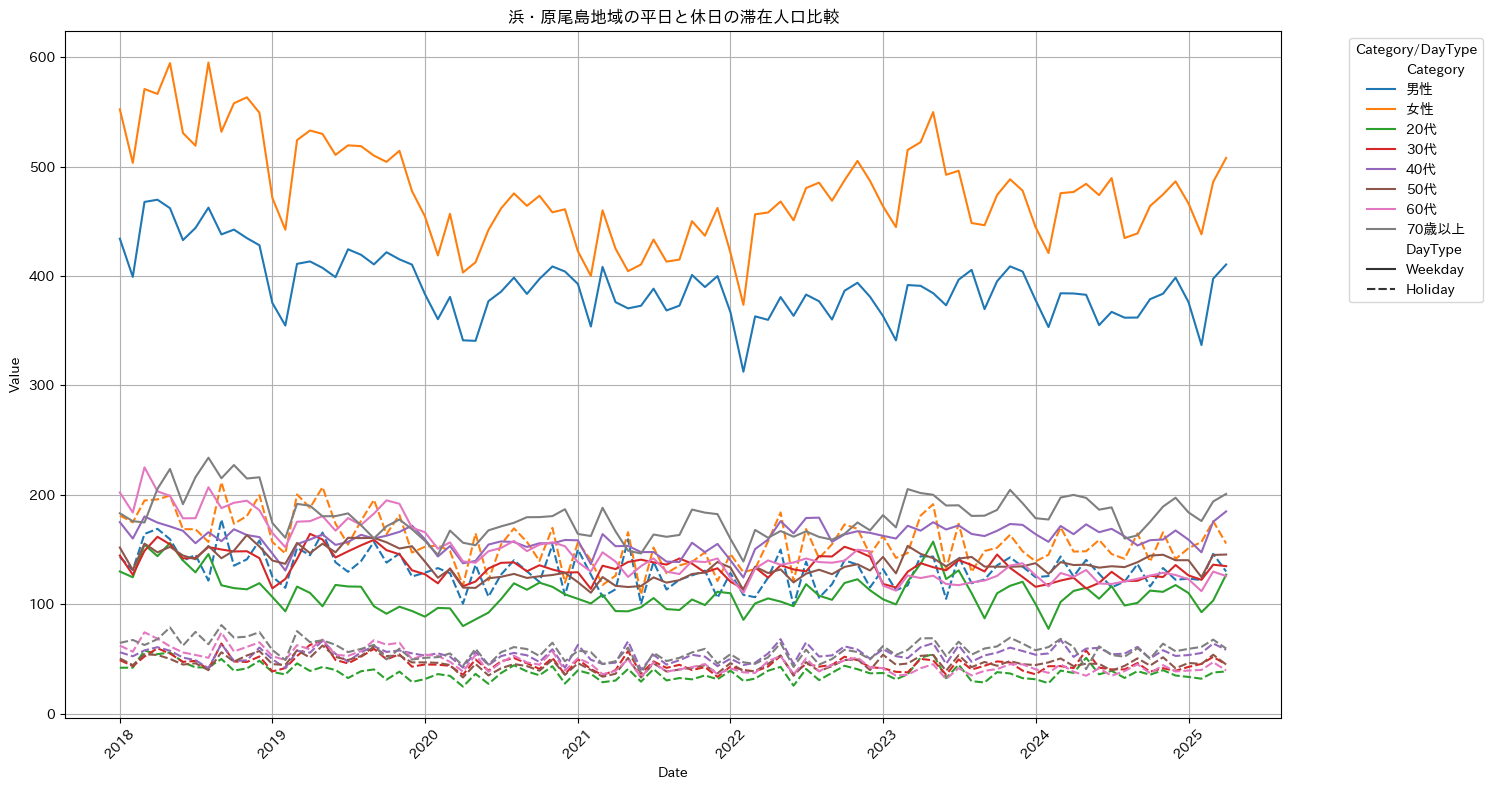

In [58]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=hama_haraojima_combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('浜・原尾島地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 西大寺地域の平日と休日の滞在人口比較

In [59]:
saidaiji_df = pd.read_csv('saidaiji_month.csv', encoding="cp932", header=1)
saidaiji_df.head()

,西大寺,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,301.8,391.7,56.4,105.6,117.0,101.6,123.5,189.4,...,NaN,祝休日,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57.0
1,2018年2月,期間全体,302.5,400.6,53.9,98.7,116.7,103.7,130.7,199.3,...,NaN,祝休日,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9
2,2018年3月,期間全体,308.3,409.0,50.3,111.4,129.4,108.2,131.1,187.0,...,NaN,祝休日,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6
3,2018年4月,期間全体,313.9,421.1,77.8,106.5,122.4,100.8,127.9,199.5,...,NaN,祝休日,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1
4,2018年5月,期間全体,334.7,468.2,84.9,109.8,128.8,104.1,133.0,242.4,...,NaN,祝休日,106.0,148.4,31.4,33.8,42.9,30.5,42.0,73.6


In [60]:
saidaiji_df = saidaiji_df.rename(columns={'西大寺': 'ds'})
saidaiji_df['ds'] = saidaiji_df['ds'].str.replace('年', '-').str.replace('月', '-01')
saidaiji_df['ds'] = pd.to_datetime(saidaiji_df['ds'])

# Define common demographic columns
demographic_columns = ['男性', '女性', '20代', '30代', '40代', '50代', '60代', '70歳以上']

# Create saidaiji_weekday_df
saidaiji_weekday_df = saidaiji_df[['ds'] + demographic_columns].copy()

# Create saidaiji_holiday_df
holiday_cols_mapping = {f'{col}.2': col for col in demographic_columns}
saidaiji_holiday_df = saidaiji_df[['ds'] + list(holiday_cols_mapping.keys())].copy()
saidaiji_holiday_df = saidaiji_holiday_df.rename(columns=holiday_cols_mapping)

print("Saidaiji Weekday DataFrame Head:")
print(saidaiji_weekday_df.head())
print("\nSaidaiji Holiday DataFrame Head:")
print(saidaiji_holiday_df.head())

Saidaiji Weekday DataFrame Head:
          ds     男性     女性   20代    30代    40代    50代    60代  70歳以上
0 2018-01-01  301.8  391.7  56.4  105.6  117.0  101.6  123.5  189.4
1 2018-02-01  302.5  400.6  53.9   98.7  116.7  103.7  130.7  199.3
2 2018-03-01  308.3  409.0  50.3  111.4  129.4  108.2  131.1  187.0
3 2018-04-01  313.9  421.1  77.8  106.5  122.4  100.8  127.9  199.5
4 2018-05-01  334.7  468.2  84.9  109.8  128.8  104.1  133.0  242.4

Saidaiji Holiday DataFrame Head:
          ds     男性     女性   20代   30代   40代   50代   60代  70歳以上
0 2018-01-01   95.8  117.7  17.7  33.9  37.7  29.9  37.4   57.0
1 2018-02-01  103.3  123.9  19.6  34.4  40.3  33.5  40.7   58.9
2 2018-03-01   98.4  133.5  20.4  35.8  41.4  33.8  41.9   58.6
3 2018-04-01  106.4  140.8  29.7  35.5  40.3  33.7  40.8   67.1
4 2018-05-01  106.0  148.4  31.4  33.8  42.9  30.5  42.0   73.6


In [61]:
saidaiji_weekday_melted = saidaiji_weekday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
saidaiji_weekday_melted['DayType'] = 'Weekday'

saidaiji_holiday_melted = saidaiji_holiday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
saidaiji_holiday_melted['DayType'] = 'Holiday'

saidaiji_weekday_melted['Value'] = pd.to_numeric(saidaiji_weekday_melted['Value'])
saidaiji_holiday_melted['Value'] = pd.to_numeric(saidaiji_holiday_melted['Value'])

saidaiji_combined_df = pd.concat([saidaiji_weekday_melted, saidaiji_holiday_melted], ignore_index=True)

print("Saidaiji Combined DataFrame Head:")
print(saidaiji_combined_df.head())
print("\nSaidaiji Combined DataFrame Tail:")
print(saidaiji_combined_df.tail())

Saidaiji Combined DataFrame Head:
          ds Category  Value  DayType
0 2018-01-01       男性  301.8  Weekday
1 2018-02-01       男性  302.5  Weekday
2 2018-03-01       男性  308.3  Weekday
3 2018-04-01       男性  313.9  Weekday
4 2018-05-01       男性  334.7  Weekday

Saidaiji Combined DataFrame Tail:
             ds Category  Value  DayType
1403 2024-12-01    70歳以上   50.3  Holiday
1404 2025-01-01    70歳以上   52.5  Holiday
1405 2025-02-01    70歳以上   54.9  Holiday
1406 2025-03-01    70歳以上   58.8  Holiday
1407 2025-04-01    70歳以上   43.7  Holiday


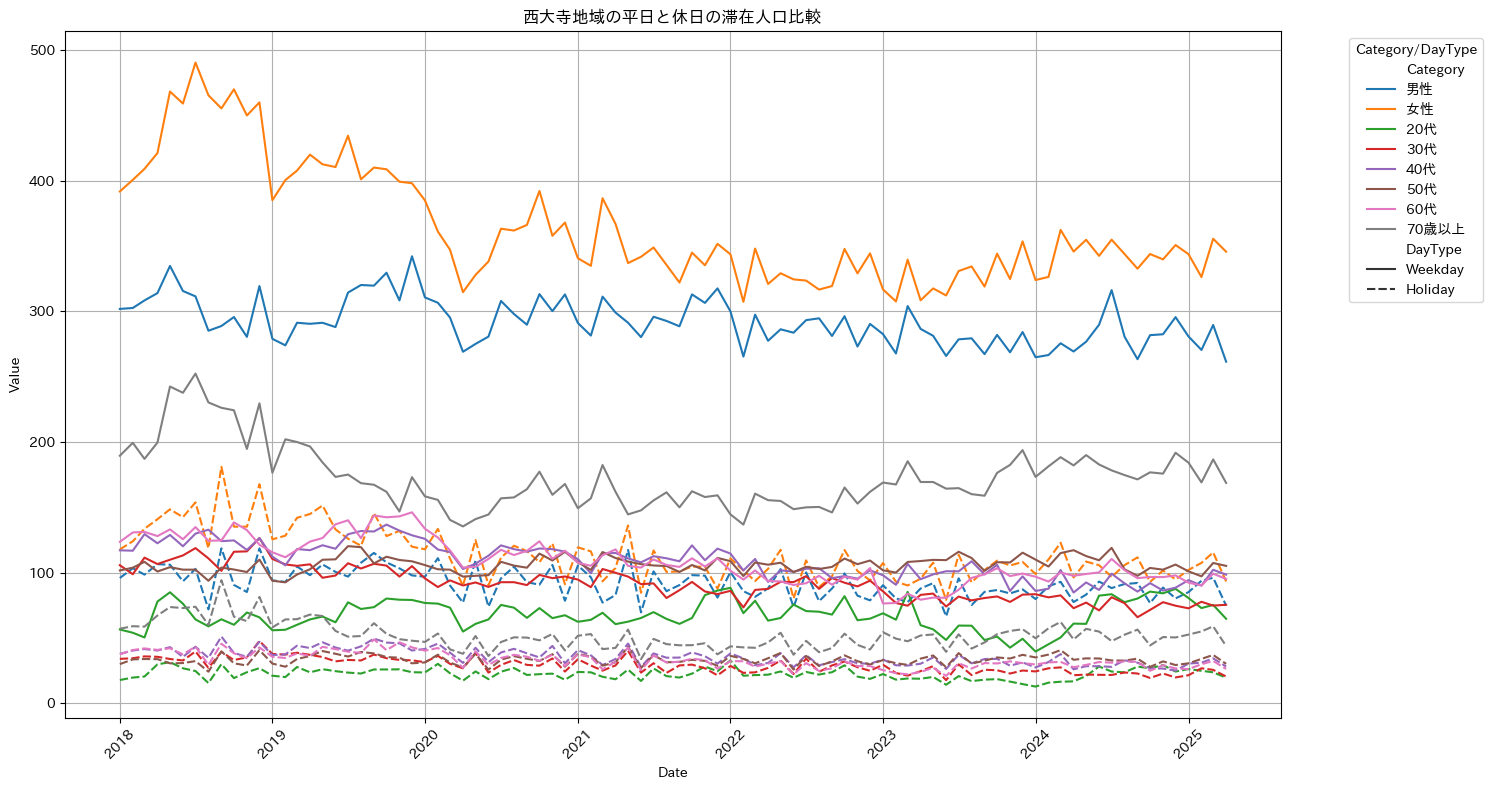

In [62]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=saidaiji_combined_df, x='ds', y='Value', hue='Category', style='DayType')
plt.title('西大寺地域の平日と休日の滞在人口比較')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category/DayType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()